In [90]:
df['loan_int_rate'] = pd.to_numeric(df['loan_int_rate'], errors='coerce')

In [92]:
df['cb_person_default_on_file'] = (df['cb_person_default_on_file'].map({'Y':1,'N':0}))

In [93]:
bool_columns = df.select_dtypes(include='bool').columns

df[bool_columns] = df[bool_columns].astype(int)

## Split before another cleaning + Data preprocessing + feature engineering

In [94]:
X = df.drop(columns='loan_status')
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [95]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26059, 11)
(6515, 11)
(26059,)
(6515,)


In [96]:
X_train['emp_length_missing'] = X_train['person_emp_length'].isna().astype(int)
X_test['emp_length_missing'] = X_test['person_emp_length'].isna().astype(int)

X_train['person_emp_length'] = X_train['person_emp_length'].fillna(X_train['person_emp_length'].median())
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(X_test['person_emp_length'].median())

In [97]:
X_train['loan_int_rate_missing'] = X_train['loan_int_rate'].isna().astype(float)
X_test['loan_int_rate_missing'] = X_test['loan_int_rate'].isna().astype(float)

X_train['loan_int_rate'] = (
    X_train.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
)
X_test['loan_int_rate'] = (
    X_test.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
)

In [117]:
X_train.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,emp_length_missing,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,person_age_woe,person_income_woe,person_emp_length_woe,loan_amnt_woe,loan_int_rate_woe,loan_percent_income_woe,cb_person_cred_hist_length_woe
27329,0.100958,1.112754,-0.023552,3.0,-0.255074,-1.839414,0.651520,0,0.123206,0,...,0.0,0.0,0.0,0.100958,1.112754,-0.023552,-0.255074,-1.839414,0.651520,0.123206
28739,0.048140,1.026382,0.178377,0.0,-0.255074,0.891642,0.651520,0,0.054220,0,...,0.0,0.0,1.0,0.048140,1.026382,0.178377,-0.255074,0.891642,0.651520,0.054220
2338,0.006046,-0.823961,-0.220974,4.0,-0.012280,-1.573501,0.816618,1,-0.015112,0,...,0.0,0.0,1.0,0.006046,-0.823961,-0.220974,-0.012280,-1.573501,0.816618,-0.015112
11627,-0.227116,0.471975,0.178377,0.0,0.139411,1.005669,0.651520,0,-0.118526,0,...,0.0,0.0,0.0,-0.227116,0.471975,0.178377,0.139411,1.005669,0.651520,-0.118526
32541,-0.008136,1.112754,0.295370,3.0,-0.694223,-0.303833,0.538185,0,-0.007692,0,...,0.0,0.0,0.0,-0.008136,1.112754,0.295370,-0.694223,-0.303833,0.538185,-0.007692


## Libraries

In [2]:
#pip install optbinning

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://nexus.fortisbank.com.pl/repository/nxrm-p-pip-pypi/simple, https://nexus.fortisbank.com.pl/repository/ptgo-h-pypi-prod/simple

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from optbinning import OptimalBinning
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## Data

In [64]:
df = pd.read_csv("/home/ailab-user/workspace/work/work work work/credit risk/credit_risk_dataset.csv")
df_raw = df.copy()

In [65]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [67]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Widać pewne problemy z danymi. Wartości maksymalne w person_age i person_emp_length zapewne są wartościami odstającymi.

In [68]:
df.shape

(32581, 12)

In [69]:
#występują puste wartości, później będziemy się nimi zajmować
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [70]:
(df.isna().sum() / len(df)) * 100

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [71]:
df.duplicated().sum()

np.int64(165)

In [72]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

## EDA

In [73]:
#class is highly inbalanced, that is normal in credit risk, so we have to have in in mind
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [74]:
#as we can see we have 4 categorical columns that we'll have to encoded them later on
categorical_columns = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']
for col in categorical_columns:
    print(df[col].value_counts())
    print( )

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64



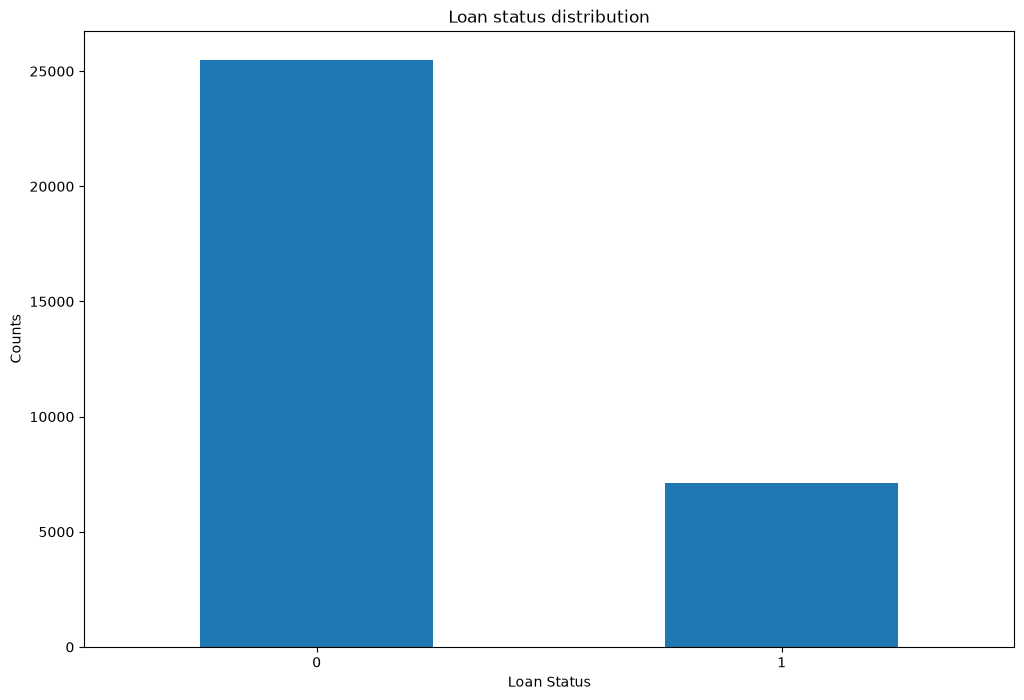

In [75]:
fig = plt.subplots(figsize =(12, 8)) 

df['loan_status'].value_counts().plot(kind='bar')

plt.xlabel('Loan Status')
plt.ylabel('Counts')
plt.title('Loan status distribution')

plt.xticks(rotation=0)

plt.show()

In [76]:
for col in categorical_columns:
    print(pd.crosstab(df[col], df['loan_status'], normalize='index')* 100)
    print()

loan_status                    0          1
person_home_ownership                      
MORTGAGE               87.429337  12.570663
OTHER                  69.158879  30.841121
OWN                    92.530960   7.469040
RENT                   68.430013  31.569987

loan_status                0          1
loan_intent                            
DEBTCONSOLIDATION  71.412126  28.587874
EDUCATION          82.783202  17.216798
HOMEIMPROVEMENT    73.897365  26.102635
MEDICAL            73.299292  26.700708
PERSONAL           80.112298  19.887702
VENTURE            85.189718  14.810282

loan_status          0          1
loan_grade                       
A            90.043611   9.956389
B            83.724046  16.275954
C            79.266027  20.733973
D            40.954220  59.045780
E            35.580913  64.419087
F            29.460581  70.539419
G             1.562500  98.437500

loan_status                        0          1
cb_person_default_on_file                      
N          

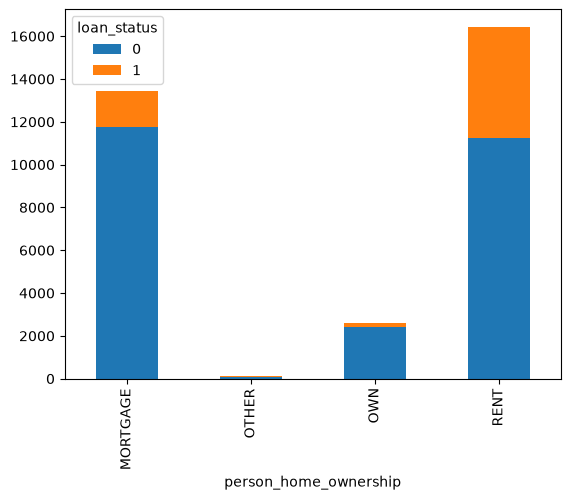

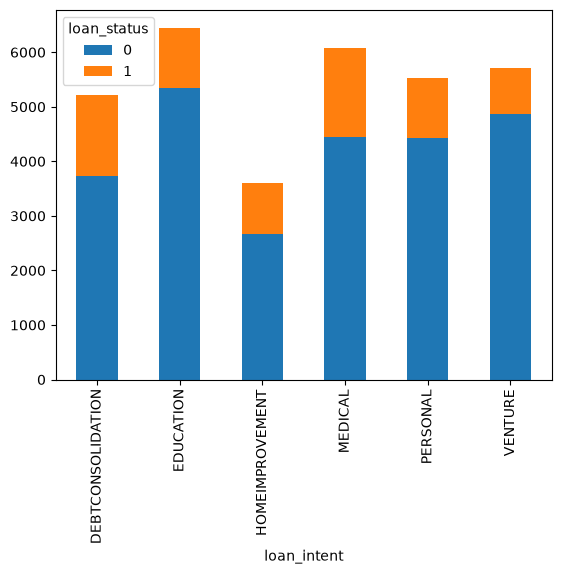

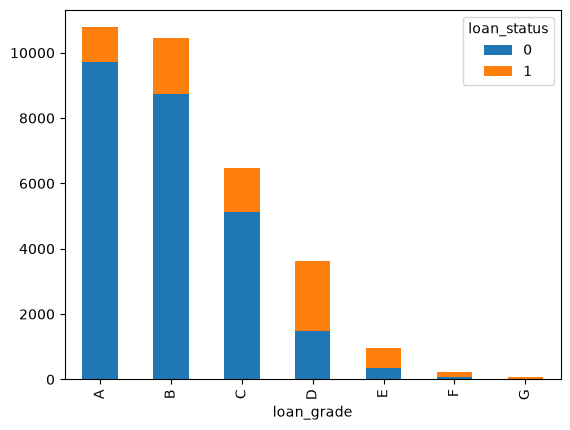

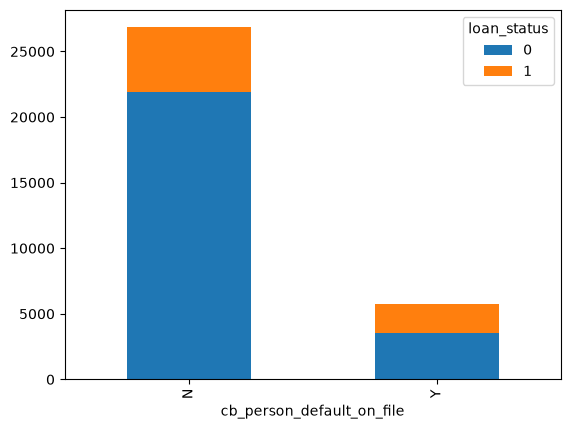

In [77]:
for col in categorical_columns:
    cross = pd.crosstab(df[col], df['loan_status'])
    cross.plot(kind='bar', stacked=True)

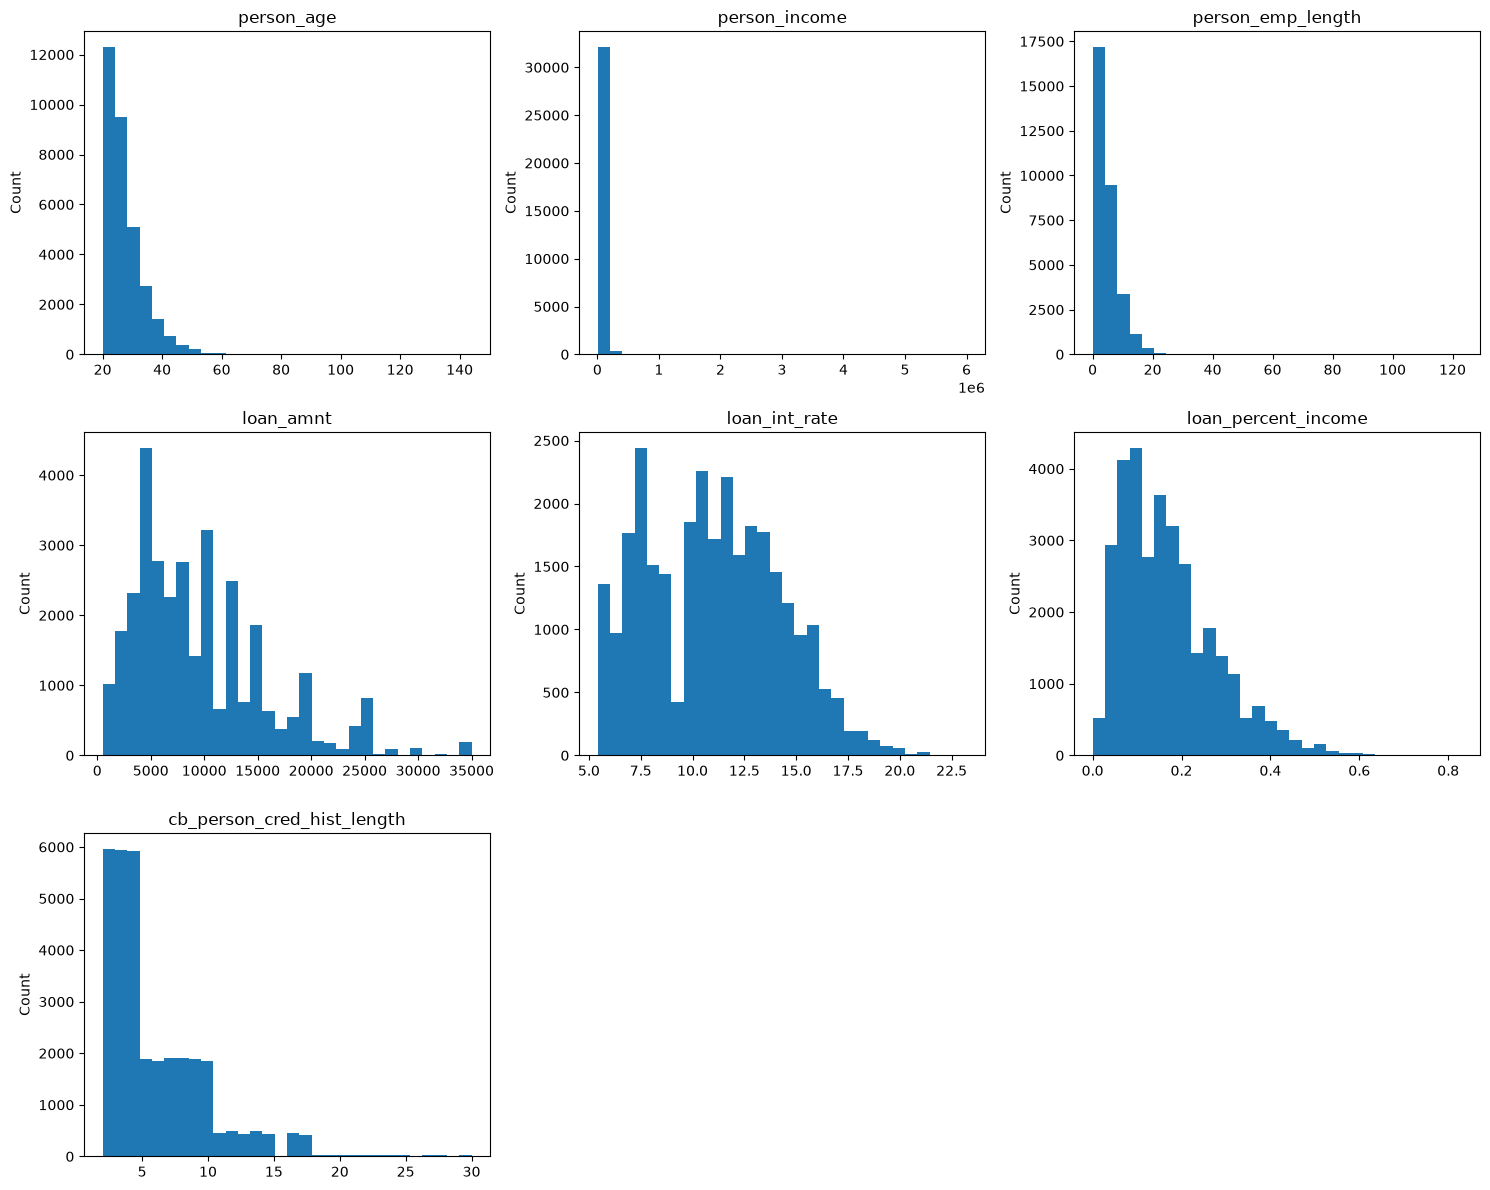

In [78]:
#większość histogramów jest prawoskośna
numeric_columns = ['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))

axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

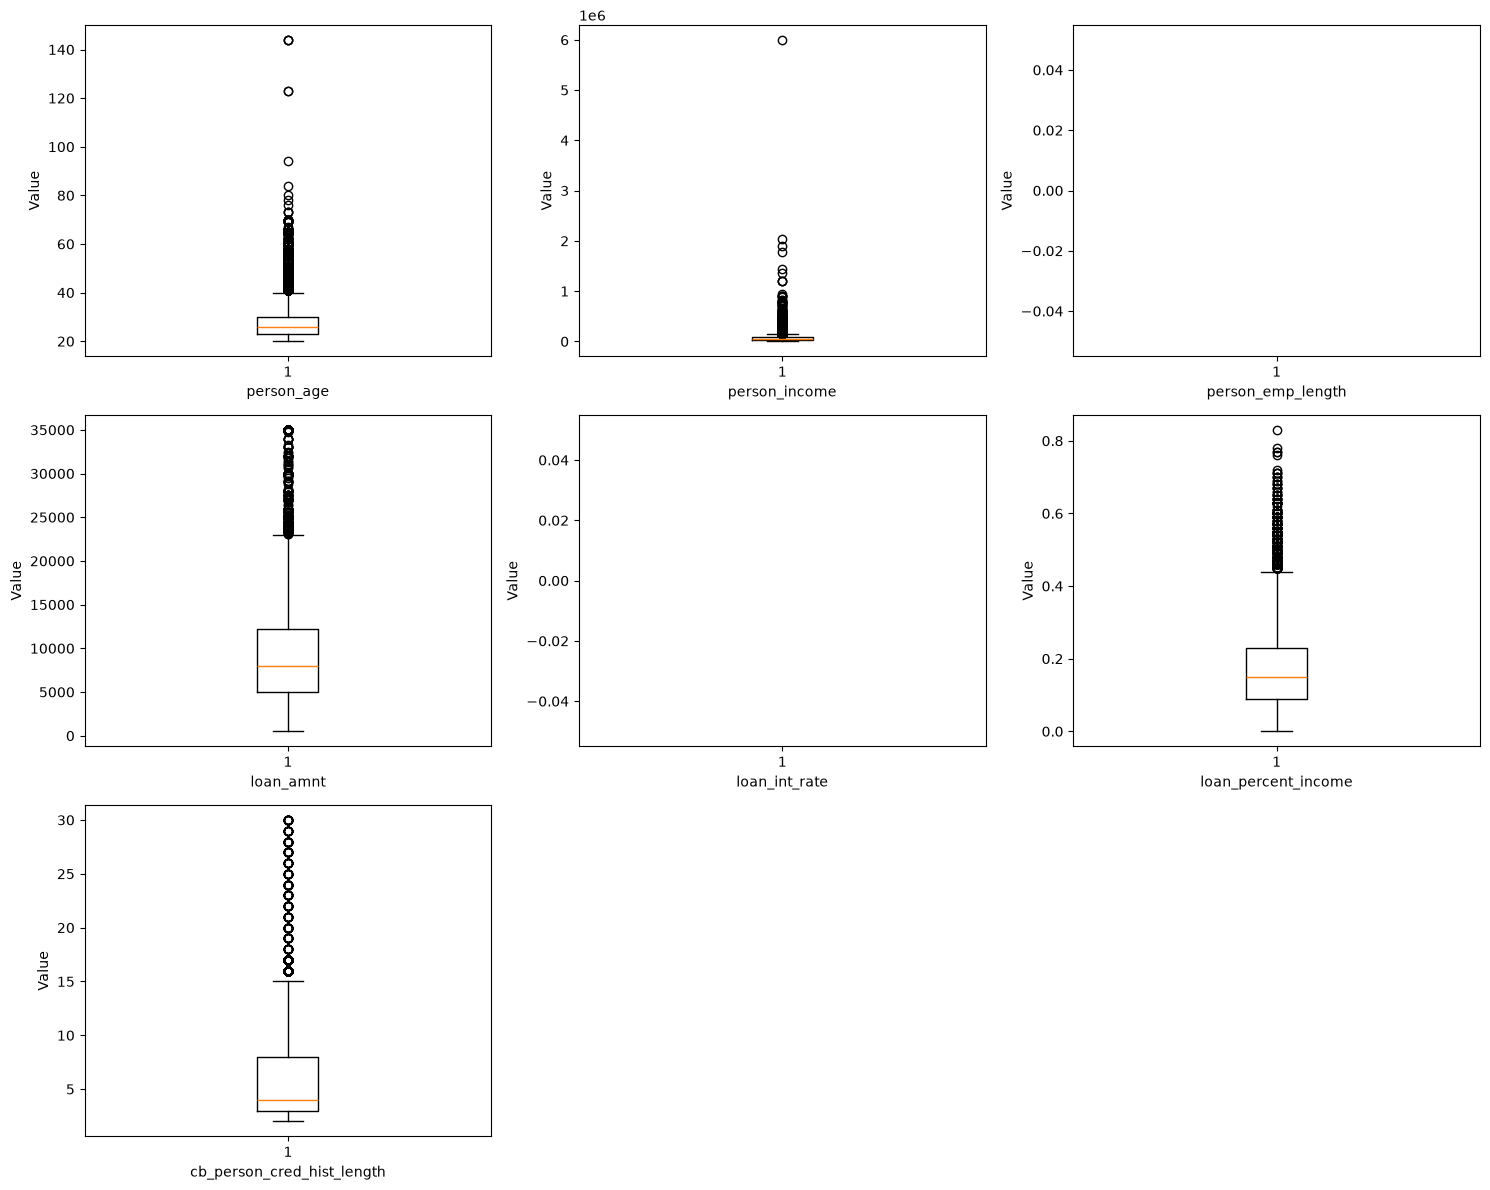

In [79]:
#widzimy dużo outlierów, ale nie wszystkie wydają się być złe, niektóre wartosci dla wcześniej wymienionych
#danych odnośnie wieku są do wyrzucenia, ale wartości z wielkością kredytu wydają się być poprawne
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    axes[i].boxplot(df[col])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Value')

for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])
    
    
plt.tight_layout()
plt.show()

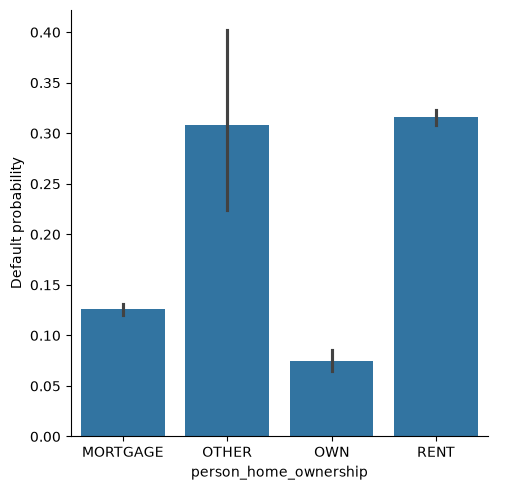

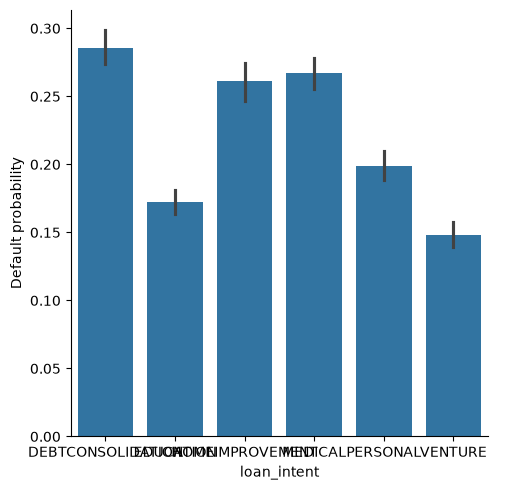

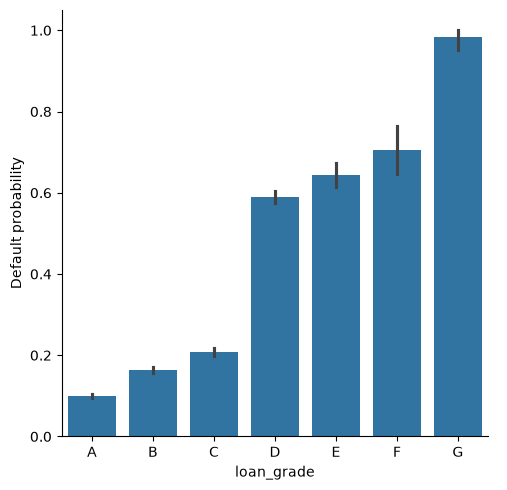

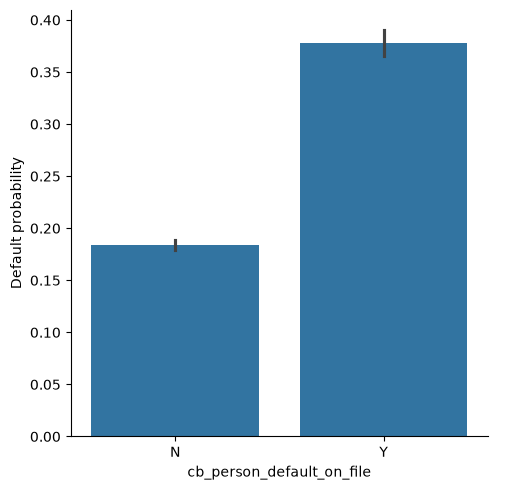

In [80]:
#widać wysoką zależność między grade a defaultem, co jest zgodne z logicznym myśleniem, że im niższa oceana tym większa szansa na default

for col in categorical_columns:
    sns.catplot(data=df.sort_values(col), x=col,y='loan_status', kind='bar')
    plt.ylabel("Default probability")

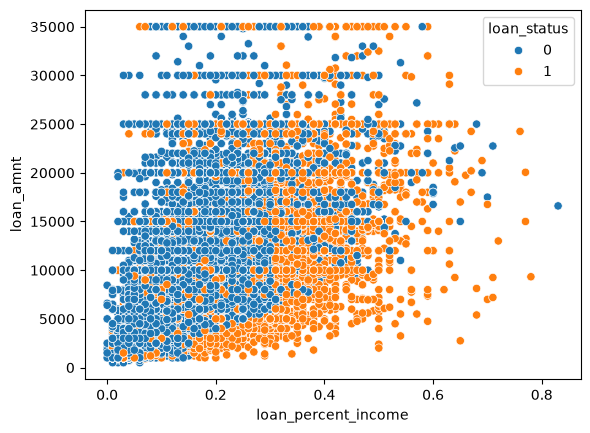

In [81]:
sns.scatterplot(
    data=df,
    x='loan_percent_income',
    y='loan_amnt',
    hue='loan_status'
)

plt.show()

<Axes: xlabel='loan_status', ylabel='person_income'>

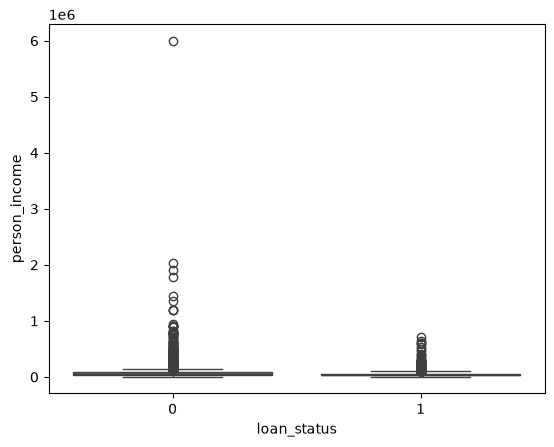

In [82]:
sns.boxplot(
    data=df,
    x='loan_status',
    y='person_income'
)

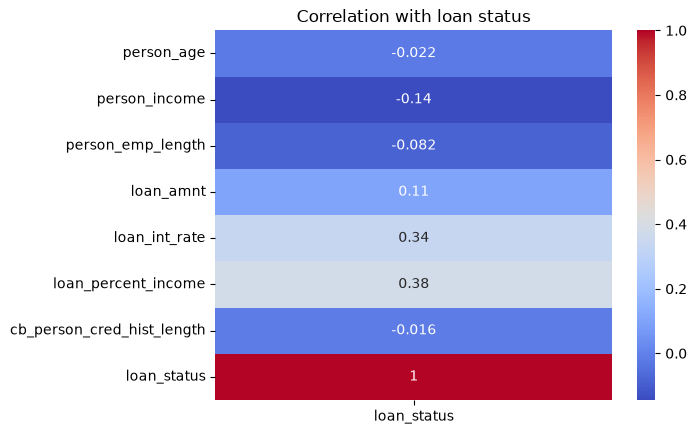

In [83]:
corr = df[numeric_columns + ['loan_status']].corr()

sns.heatmap(
    corr[['loan_status']],
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation with loan status')
plt.show()

In [84]:
correlation_table = corr[['loan_status']].sort_values(by='loan_status', ascending=False)

print("Korelacja cech z loan_status:")
print(correlation_table)

Korelacja cech z loan_status:
                            loan_status
loan_status                    1.000000
loan_percent_income            0.379366
loan_int_rate                  0.335133
loan_amnt                      0.105376
cb_person_cred_hist_length    -0.015529
person_age                    -0.021629
person_emp_length             -0.082489
person_income                 -0.144449


<Axes: >

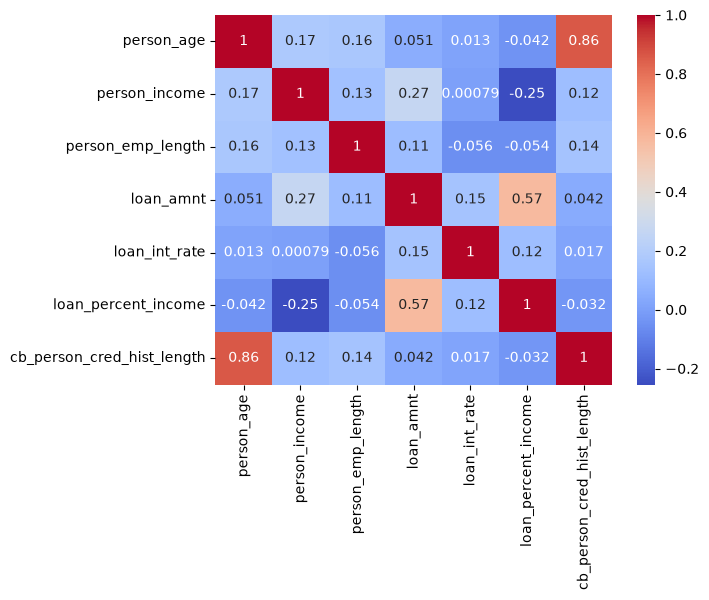

In [85]:
corr_matrix = df[numeric_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

In [86]:
print(corr_matrix)

                            person_age  person_income  person_emp_length  \
person_age                    1.000000       0.173202           0.163106   
person_income                 0.173202       1.000000           0.134268   
person_emp_length             0.163106       0.134268           1.000000   
loan_amnt                     0.050787       0.266820           0.113082   
loan_int_rate                 0.012580       0.000792          -0.056405   
loan_percent_income          -0.042411      -0.254471          -0.054111   
cb_person_cred_hist_length    0.859133       0.117987           0.144699   

                            loan_amnt  loan_int_rate  loan_percent_income  \
person_age                   0.050787       0.012580            -0.042411   
person_income                0.266820       0.000792            -0.254471   
person_emp_length            0.113082      -0.056405            -0.054111   
loan_amnt                    1.000000       0.146813             0.572612   
loan_i

## Data cleaning 

In [87]:
df[df['person_emp_length'] > df['person_age']]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [88]:
#deleting rows with age > 100 and person_emp_length should be <= then person_age - 15
df = df[df['person_age'] <= 100]
df = df[(df['person_emp_length'] <= df['person_age'] - 15) | (df['person_emp_length'].isna())]

In [89]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3115
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [90]:
df['loan_int_rate'] = pd.to_numeric(df['loan_int_rate'], errors='coerce')

In [91]:
pd.crosstab(df['loan_int_rate'].isna(), df['loan_status'], normalize='index')

loan_status,0,1
loan_int_rate,,
False,0.780610,0.219390
True,0.793258,0.206742


In [92]:
df['cb_person_default_on_file'] = (df['cb_person_default_on_file'].map({'Y':1,'N':0}))

In [93]:
bool_columns = df.select_dtypes(include='bool').columns

df[bool_columns] = df[bool_columns].astype(int)

## Split before another cleaning + Data preprocessing + feature engineering

In [94]:
X = df.drop(columns='loan_status')
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [95]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26059, 11)
(6515, 11)
(26059,)
(6515,)


## Data preprocessing + feature engineering

In [96]:
X_train['emp_length_missing'] = X_train['person_emp_length'].isna().astype(int)
X_test['emp_length_missing'] = X_test['person_emp_length'].isna().astype(int)

X_train['person_emp_length'] = X_train['person_emp_length'].fillna(X_train['person_emp_length'].median())
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(X_test['person_emp_length'].median())

In [97]:
X_train['loan_int_rate_missing'] = X_train['loan_int_rate'].isna().astype(float)
X_test['loan_int_rate_missing'] = X_test['loan_int_rate'].isna().astype(float)

X_train['loan_int_rate'] = (
    X_train.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
)
X_test['loan_int_rate'] = (
    X_test.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
)

In [98]:
#OrdinalEncoder, cause A is better then B in credit risk (in this particular example)
oe = OrdinalEncoder(categories=[['A','B','C','D','E','F','G']])

X_train['loan_grade'] = oe.fit_transform(X_train[['loan_grade']])

X_test['loan_grade'] = oe.transform(X_test[['loan_grade']])

In [99]:
columns_to_encode = ['loan_intent', 'person_home_ownership']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

X_train_encoded = ohe.fit_transform(X_train[columns_to_encode])

X_test_encoded = ohe.transform(X_test[columns_to_encode])

X_train_encoded = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(columns_to_encode), index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(columns_to_encode), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=columns_to_encode), X_train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=columns_to_encode), X_test_encoded], axis=1)

In [107]:
columns_for_binning = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

X_train_binned = X_train.copy()
X_test_binned = X_test.copy()

for col in columns_for_binning:
    optb = OptimalBinning(name=col, dtype="numerical", solver="cp")
    optb.fit(X_train[col], y_train)  
    print(f"\n===== {col} =====")
    print(optb.binning_table.build())
    
    X_train_binned[col] = optb.transform(X_train[col])
    X_test_binned[col] = optb.transform(X_test[col])

X_train = X_train_binned
X_test = X_test_binned


===== person_age =====
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, 22.50)   3936   0.151042       2915   1021    0.259400   
1       [22.50, 25.50)   8353   0.320542       6539   1814    0.217167   
2       [25.50, 28.50)   5204   0.199701       4099   1105    0.212337   
3       [28.50, 29.50)   1347   0.051690       1064    283    0.210097   
4       [29.50, 31.50)   2000   0.076749       1601    399    0.199500   
5       [31.50, 34.50)   1978   0.075905       1596    382    0.193124   
6       [34.50, 38.50)   1638   0.062857       1308    330    0.201465   
7         [38.50, inf)   1603   0.061514       1251    352    0.219588   
8              Special      0   0.000000          0      0    0.000000   
9              Missing      0   0.000000          0      0    0.000000   
Totals                  26059   1.000000      20373   5686    0.218197   

             WoE        IV            JS  
0      -0.227116  0.008286  1.033495e-03  
1

In [108]:
X_train_woe = X_train.copy()
X_test_woe = X_test.copy()

for col in columns_for_binning:
    optb = OptimalBinning(name=col, dtype="numerical", solver="cp")
    optb.fit(X_train[col], y_train) 
    print(f"\n===== {col} =====")
    print(optb.binning_table.build())
    
    X_train_woe[col + "_woe"] = optb.transform(X_train[col], metric="woe")
    
    X_test_woe[col + "_woe"] = optb.transform(X_test[col], metric="woe")

X_train = X_train_woe
X_test = X_test_woe


===== person_age =====
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -0.12)   3936   0.151042       2915   1021    0.259400   
1       [-0.12, -0.00)   1603   0.061514       1251    352    0.219588   
2        [-0.00, 0.02)   8353   0.320542       6539   1814    0.217167   
3         [0.02, 0.04)   5204   0.199701       4099   1105    0.212337   
4         [0.04, 0.07)   1347   0.051690       1064    283    0.210097   
5         [0.07, 0.11)   1638   0.062857       1308    330    0.201465   
6         [0.11, 0.13)   2000   0.076749       1601    399    0.199500   
7          [0.13, inf)   1978   0.075905       1596    382    0.193124   
8              Special      0   0.000000          0      0    0.000000   
9              Missing      0   0.000000          0      0    0.000000   
Totals                  26059   1.000000      20373   5686    0.218197   

             WoE        IV            JS  
0      -0.227116  0.008286  1.033495e-03  
1

In [111]:
iv_dict = {}

for col in columns_for_binning:
    optb = OptimalBinning(name=col, dtype="numerical", solver="cp")
    optb.fit(X_train[col], y_train)
    optb.binning_table.build()  
    iv_dict[col] = optb.binning_table.iv
    print(f"IV dla {col}: {optb.binning_table.iv:.4f}")

IV dla person_age: 0.0119
IV dla person_income: 0.5933
IV dla person_emp_length: 0.0575
IV dla loan_amnt: 0.0916
IV dla loan_int_rate: 0.7674
IV dla loan_percent_income: 0.9589
IV dla cb_person_cred_hist_length: 0.0051


Values > 0.5 should be rethink, because it is suspicion to have such high value. However, when we will take everything into consideration and analyse this data from business side loan_percent_income can be that high. loan_int_rate it's very different, cause it depends on knowledge about interest (does the bank know the interest before clent applied for a credit?). We will do 2 different models to see how it will react

In [112]:
for col in columns_for_binning:
    optb = OptimalBinning(name=col, dtype="numerical", solver="cp")
    optb.fit(X_train[col], y_train) 
    optb.binning_table.build()  
    
    print(f"\n===== {col} =====")
    print(optb.binning_table.build()[['Bin', 'Count', 'Event rate', 'WoE']])


===== person_age =====
                   Bin  Count  Event rate       WoE
0        (-inf, -0.12)   3936    0.259400 -0.227116
1       [-0.12, -0.00)   1603    0.219588 -0.008136
2        [-0.00, 0.02)   8353    0.217167  0.006046
3         [0.02, 0.04)   5204    0.212337  0.034694
4         [0.04, 0.07)   1347    0.210097   0.04814
5         [0.07, 0.11)   1638    0.201465  0.100958
6         [0.11, 0.13)   2000    0.199500  0.113219
7          [0.13, inf)   1978    0.193124  0.153632
8              Special      0    0.000000       0.0
9              Missing      0    0.000000       0.0
Totals                  26059    0.218197          

===== person_income =====
                   Bin  Count  Event rate       WoE
0        (-inf, -1.33)   1324    0.638218  -1.84384
1       [-1.33, -0.55)   3634    0.388828 -0.823961
2       [-0.55, -0.13)   1856    0.269397 -0.278517
3        [-0.13, 0.04)   3868    0.213806  0.025934
4         [0.04, 0.27)   3494    0.208071  0.060389
5         [0.

In [117]:
X_train.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,emp_length_missing,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,person_age_woe,person_income_woe,person_emp_length_woe,loan_amnt_woe,loan_int_rate_woe,loan_percent_income_woe,cb_person_cred_hist_length_woe
27329,0.100958,1.112754,-0.023552,3.0,-0.255074,-1.839414,0.651520,0,0.123206,0,...,0.0,0.0,0.0,0.100958,1.112754,-0.023552,-0.255074,-1.839414,0.651520,0.123206
28739,0.048140,1.026382,0.178377,0.0,-0.255074,0.891642,0.651520,0,0.054220,0,...,0.0,0.0,1.0,0.048140,1.026382,0.178377,-0.255074,0.891642,0.651520,0.054220
2338,0.006046,-0.823961,-0.220974,4.0,-0.012280,-1.573501,0.816618,1,-0.015112,0,...,0.0,0.0,1.0,0.006046,-0.823961,-0.220974,-0.012280,-1.573501,0.816618,-0.015112
11627,-0.227116,0.471975,0.178377,0.0,0.139411,1.005669,0.651520,0,-0.118526,0,...,0.0,0.0,0.0,-0.227116,0.471975,0.178377,0.139411,1.005669,0.651520,-0.118526
32541,-0.008136,1.112754,0.295370,3.0,-0.694223,-0.303833,0.538185,0,-0.007692,0,...,0.0,0.0,0.0,-0.008136,1.112754,0.295370,-0.694223,-0.303833,0.538185,-0.007692


In [114]:
woe_features = [
'person_income_woe',
'loan_int_rate_woe',
'loan_percent_income_woe',
'loan_amnt_woe',
'person_emp_length_woe',
'person_age_woe',
'cb_person_cred_hist_length_woe'
]

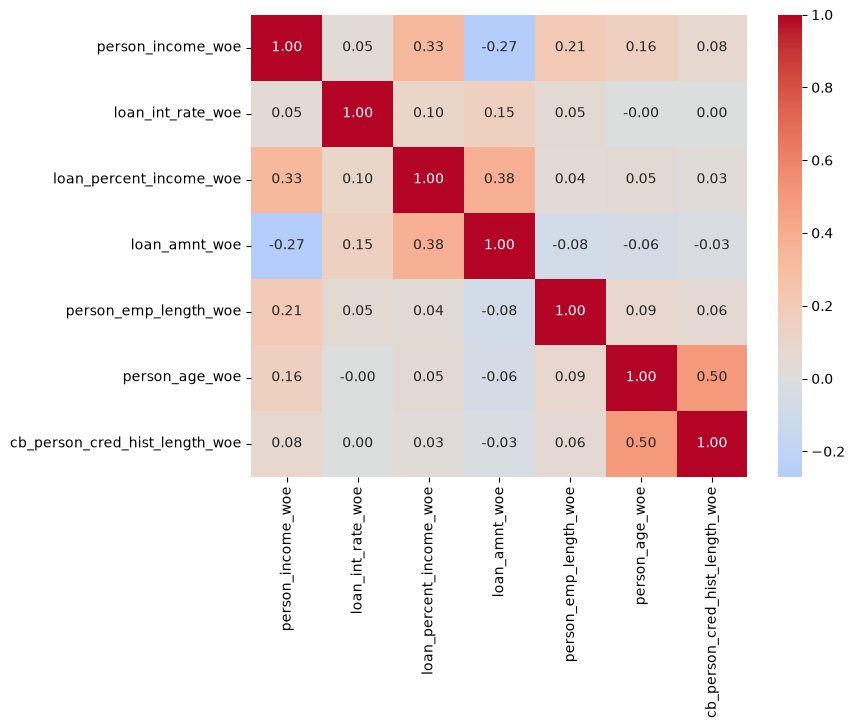

In [116]:
plt.figure(figsize=(8,6))

sns.heatmap(
    X_train[woe_features].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"   
)

plt.show()

In [118]:
X = X_train[woe_features]

vif = pd.DataFrame({
    "Feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif)

                          Feature       VIF
0               person_income_woe  1.506378
1               loan_int_rate_woe  1.049289
2         loan_percent_income_woe  1.570188
3                   loan_amnt_woe  1.506093
4           person_emp_length_woe  1.056489
5                  person_age_woe  1.358060
6  cb_person_cred_hist_length_woe  1.330003


## Modeling

In [52]:
basic_features = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_grade',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_default_on_file',
    'cb_person_cred_hist_length',
    'emp_length_missing',
    'loan_int_rate_missing',
    'loan_intent_EDUCATION',
    'loan_intent_HOMEIMPROVEMENT',
    'loan_intent_MEDICAL',
    'loan_intent_PERSONAL',
    'loan_intent_VENTURE',
    'person_home_ownership_OTHER',
    'person_home_ownership_OWN',
    'person_home_ownership_RENT'
]

In [53]:
#basic model with all the data
X = df[basic_features]
y = df["loan_status"]

In [54]:
# 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# z pozostałych 80% wydzielamy walidację
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,   # 0.25 * 0.8 = 0.2
    stratify=y_temp,
    random_state=42
)

In [56]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.mean())
print(y_val.mean())
print(y_test.mean())

(19544, 19)
(6515, 19)
(6515, 19)
0.21817437576749898
0.2182655410590944
0.21811204911742132


In [ ]:
model = LogisticRegression(max_iter = 1000, random_state=42)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)